In [22]:
%matplotlib inline
# Python packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import romberg
import math
from scipy.interpolate import interp1d

In [29]:
?romberg

In [25]:
print (3/2)

1.5


In [3]:
# Galaxy redshift distribution (~observed cut in magnitude)
def gal_z_distribution(z):
    return 1.5*np.power(2.*z,2.)*np.exp(-np.power(2.*z,1.5))

In [4]:
# Redshift bins
z_min_tab = 0.1
z_max_tab = 1.4
z_bin_edges = np.linspace(z_min_tab, z_max_tab, num=2001,endpoint=True)
print ('z_bin_edges')
print (z_bin_edges)
z_bin_mean = (z_bin_edges[0:-1]+z_bin_edges[1:])/2.
print ('z_bin_mean')
print (z_bin_mean)
print ('number of bins')
print (len(z_bin_mean))
z_bin_width = abs(z_bin_mean[1]-z_bin_mean[0])
print ('z_bin_width')
print (z_bin_width)

z_bin_edges
[0.1     0.10065 0.1013  ... 1.3987  1.39935 1.4    ]
z_bin_mean
[0.100325 0.100975 0.101625 ... 1.398375 1.399025 1.399675]
number of bins
2000
z_bin_width
0.0006500000000000117


In [5]:
# Number of galaxies as a function of redshift
dN_dz = gal_z_distribution(z_bin_edges)
print (dN_dz)

[0.05486644 0.05553349 0.05620381 ... 0.10905251 0.10879843 0.10854481]


Text(0.5, 1.0, 'Redshift galaxy distribution')

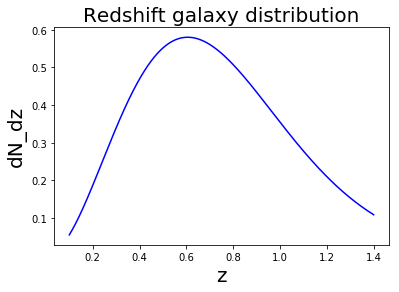

In [6]:
fig, ax = plt.subplots()
Nz_plot = ax.plot(z_bin_edges, dN_dz, color='b')
ax.set_ylabel('dN_dz',fontsize=20)
ax.set_xlabel('z',fontsize=20)
ax.set_title('Redshift galaxy distribution',fontsize=20)

In [7]:
# Normalize factor
f_norm = romberg(gal_z_distribution, z_min_tab, z_max_tab)
print (f_norm)

0.4718777067241743


Text(0.5, 1.0, 'Normalized distribution')

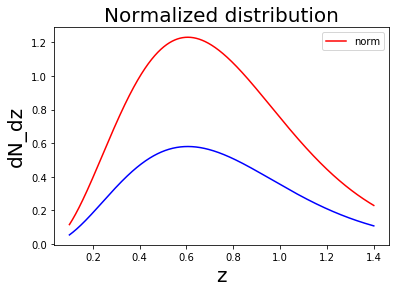

In [8]:
# pdf(z)
dN_dz_norm = dN_dz/f_norm
fig, ax = plt.subplots()
Nz_plot = ax.plot(z_bin_edges, dN_dz_norm , color='r',label='norm')
Nz_plot = ax.plot(z_bin_edges, dN_dz, color='b')
ax.legend(['norm'],loc=1)
ax.set_ylabel('dN_dz',fontsize=20)
ax.set_xlabel('z',fontsize=20)
ax.set_title('Normalized distribution',fontsize=20)

In [9]:
# Cumulative function
def cum_pdf(z):
    return romberg(gal_z_distribution, z_min_tab, z)
cum_pdf_vect = np.vectorize(cum_pdf)
# Check
print (cum_pdf(z_max_tab)/f_norm)

1.0


In [10]:
# Cumulative function tabulated
dn_dz_cum = cum_pdf_vect(z_bin_edges)/f_norm

Text(0.5, 1.0, 'Normalized distribution')

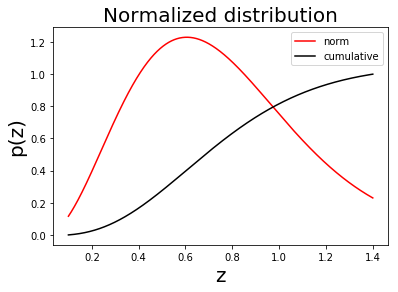

In [11]:
# cumulative pdf(z)
fig, ax = plt.subplots()
Nz_plot = ax.plot(z_bin_edges, dN_dz_norm, color='r',label='norm')
cum_Nz_plot = ax.plot(z_bin_edges, dn_dz_cum, color='k',label='cumulative')
ax.legend(['norm','cumulative'],loc=0)
ax.set_ylabel('p(z)',fontsize=20)
ax.set_xlabel('z',fontsize=20)
ax.set_title('Normalized distribution',fontsize=20)

In [12]:
# Invert function
# Fit a function to the inverse of the cumulative f(p(z),z)
f = interp1d(dn_dz_cum, z_bin_edges)

Text(0.5, 0, 'cumulative')

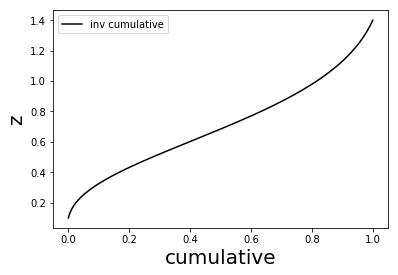

In [13]:
# Inverse cumulative
fig, ax = plt.subplots()
inv_cum_plot = ax.plot(dn_dz_cum,z_bin_edges,color='k')
ax.legend(['inv cumulative'],loc=0)
ax.set_ylabel('z',fontsize=20)
ax.set_xlabel('cumulative',fontsize=20)

In [38]:
# Create mock galaxy redshift distribution
# random numbers
Ngal = 1000000
rand_sample = np.random.random_sample((Ngal,))
# Redshifts
f_rand = f(rand_sample)
# Check
print (min(f_rand))
print (max(f_rand))

0.10001074463774631
1.3999931520024553


Text(0.5, 0, 'p(z)')

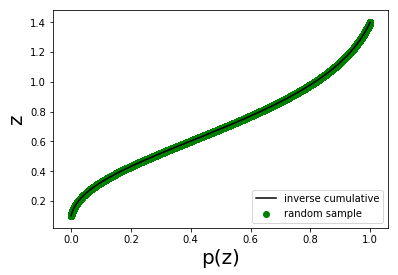

In [39]:
# Check
fig, ax = plt.subplots()
f_rand_plot = ax.scatter(rand_sample, f_rand, color='g')
inv_cum_plot = ax.plot(dn_dz_cum,z_bin_edges,color='k')
ax.legend(['inverse cumulative','random sample'],loc=4)
ax.set_ylabel('z',fontsize=20)
ax.set_xlabel('p(z)',fontsize=20)

20
21
[0.1325 0.1975 0.2625 0.3275 0.3925 0.4575 0.5225 0.5875 0.6525 0.7175
 0.7825 0.8475 0.9125 0.9775 1.0425 1.1075 1.1725 1.2375 1.3025 1.3675]
0.06499999999999997


Text(0.5, 1.0, 'Normalized distribution')

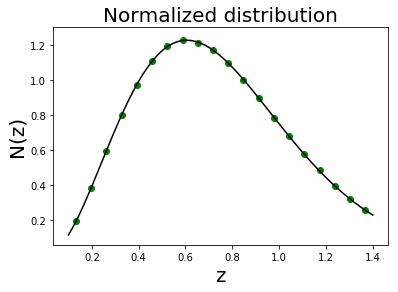

In [40]:
# Plots
# Histogram
hist, hist_edges = np.histogram(f_rand, bins=20, range=(z_min_tab,z_max_tab))
#print hist
#print hist_edges
print (len(hist))
print (len(hist_edges))

hist_mean = (hist_edges[0:-1]+hist_edges[1:]) /2
print (hist_mean)
hist_width = abs(hist_edges[1]-hist_edges[0])
print (hist_width)

# Normalized histogram
hist_norm = (hist/float(Ngal))/hist_width

# Figure
fig, ax = plt.subplots()
f_rand_plot = ax.scatter(hist_mean, hist_norm, color='g',label='hist norm')
Nz_plot = ax.plot(z_bin_edges, dN_dz_norm , color='k',label='norm')
ax.set_ylabel('N(z)',fontsize=20)
ax.set_xlabel('z',fontsize=20)
ax.set_title('Normalized distribution',fontsize=20)

In [42]:
# "normal" distribution of dark matter particles assuming the mean density is constant in redshift
def diff_sphere_volume(z):
    return math.pi*np.power(z,2)/2.

In [21]:
# Number of dark matter particles as a function of redshift
dNdm_dz = diff_sphere_volume(z_bin_mean)
print (dNdm_dz)

[0.01581023 0.01601576 0.01622262 ... 3.07161783 3.07447402 3.07733154]
